In [1]:
import os
import math
import pickle
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import statsmodels.stats.multitest
from tqdm import tqdm

import pyBigWig
import pyranges1 as pr
import datasources
from knots_tools import *

In [2]:
ccds, _ = load_cknots_base_data()
ccds = ccds.query('dataset == "GM12878" & length < 2e7').copy()

# ChIP-Seq

In [5]:
metrics, peaks, peak_to_ccd, peak_to_boundary = calculate_ctcf_metrics(
    ccds=ccds,
    peak_bigbed_path="./data/chipseq/ENCFF182CAX.bigBed",
    signal_bigwig_path="./data/chipseq/ENCFF279CYY.bigWig",
    boundary_radius=50_000,
)

Reading peaks from ./data/chipseq/ENCFF182CAX.bigBed
Read 40,949 peaks
Assigning peak summits to CCDs
Assigning peak summits to boundary windows
Calculating continuous bigWig signal


/tmp/ipykernel_519948/1914835437.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['non-linked', 'linked'])
/tmp/ipykernel_519948/1914835437.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['non-linked', 'linked'])
/tmp/ipykernel_519948/1914835437.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['non-linked', 'linked'])


Mann-Whitney U test: statistic=430831.5000, p-value=0.000000 (data: ctcf_peaks_per_mb). Median: non-linked=27.3663, linked=14.7467
Mann-Whitney U test: statistic=343888.0000, p-value=0.000000 (data: ctcf_peak_signal_median). Median: non-linked=71.2360, linked=59.1963
Mann-Whitney U test: statistic=433640.0000, p-value=0.000000 (data: ctcf_fc_mean). Median: non-linked=0.7849, linked=0.6614


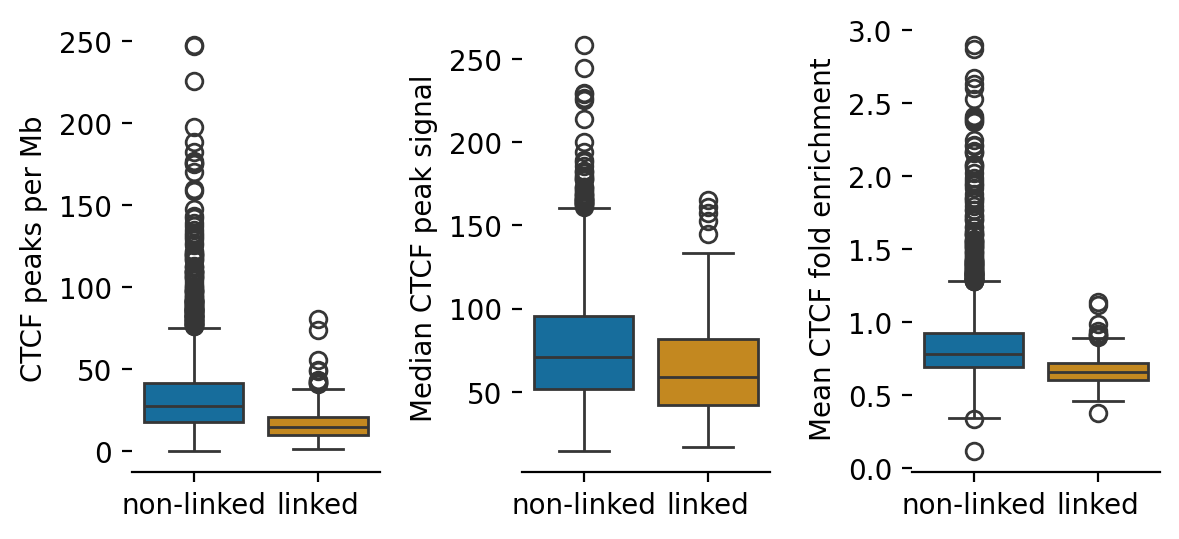

In [6]:
def compare_boxplot(df, ax, y, ylab, legend=False, test=True):
    ax = sns.boxplot(df, x='has_minors', hue='has_minors', y=y, palette='colorblind', ax=ax)
    ax.set_ylabel(ylab)
    ax.set_xlabel('')
    ax.set_xticklabels(['non-linked', 'linked'])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    if legend:        
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:2], ["non-linked", "linked"], title="CCD type");
    else:
        ax.get_legend().remove()
    if test:
        non_linked = df.query('has_minors == False')[y].dropna()
        linked = df.query('has_minors == True')[y]
        stat, pval = scipy.stats.mannwhitneyu(non_linked, linked, alternative='two-sided')
        med_non_linked = np.median(non_linked)
        med_linked = np.median(linked)
        print(f"Mann-Whitney U test: statistic={stat:.4f}, p-value={pval:.6f} (data: {y}). Median: non-linked={med_non_linked:.4f}, linked={med_linked:.4f}")
    return ax

fig, axs = plt.subplots(1, 3, figsize=(6, 2.8), dpi=200)
compare_boxplot(metrics, axs[0], "ctcf_peaks_per_mb", "CTCF peaks per Mb")
compare_boxplot(metrics, axs[1], "ctcf_peak_signal_median", "Median CTCF peak signal")
compare_boxplot(metrics, axs[2], "ctcf_fc_mean", "Mean CTCF fold enrichment")
plt.tight_layout()
# plt.savefig('./figures/ctcf.svg')